In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [3]:
# Colonnes du dataset
columns = ['unit', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

# Charger train_FD001 (le plus simple pour commencer)
train = pd.read_csv('../data/train_FD001.txt', sep=' ', header=None)
train.drop(train.columns[[26, 27]], axis=1, inplace=True)  # Colonnes vides
train.columns = columns

print(f"✓ Dataset loaded: {train.shape[0]} rows, {train.shape[1]} columns")
train.head()

✓ Dataset loaded: 20631 rows, 26 columns


,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
# Info sur le dataset
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print(f"Number of engines: {train['unit'].nunique()}")
print(f"Total cycles: {len(train)}")
print(f"Number of sensors: 21")
print(f"\nCycles per engine (statistics):")
print(train.groupby('unit')['cycle'].max().describe())

DATASET INFORMATION
Number of engines: 100
Total cycles: 20631
Number of sensors: 21

Cycles per engine (statistics):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


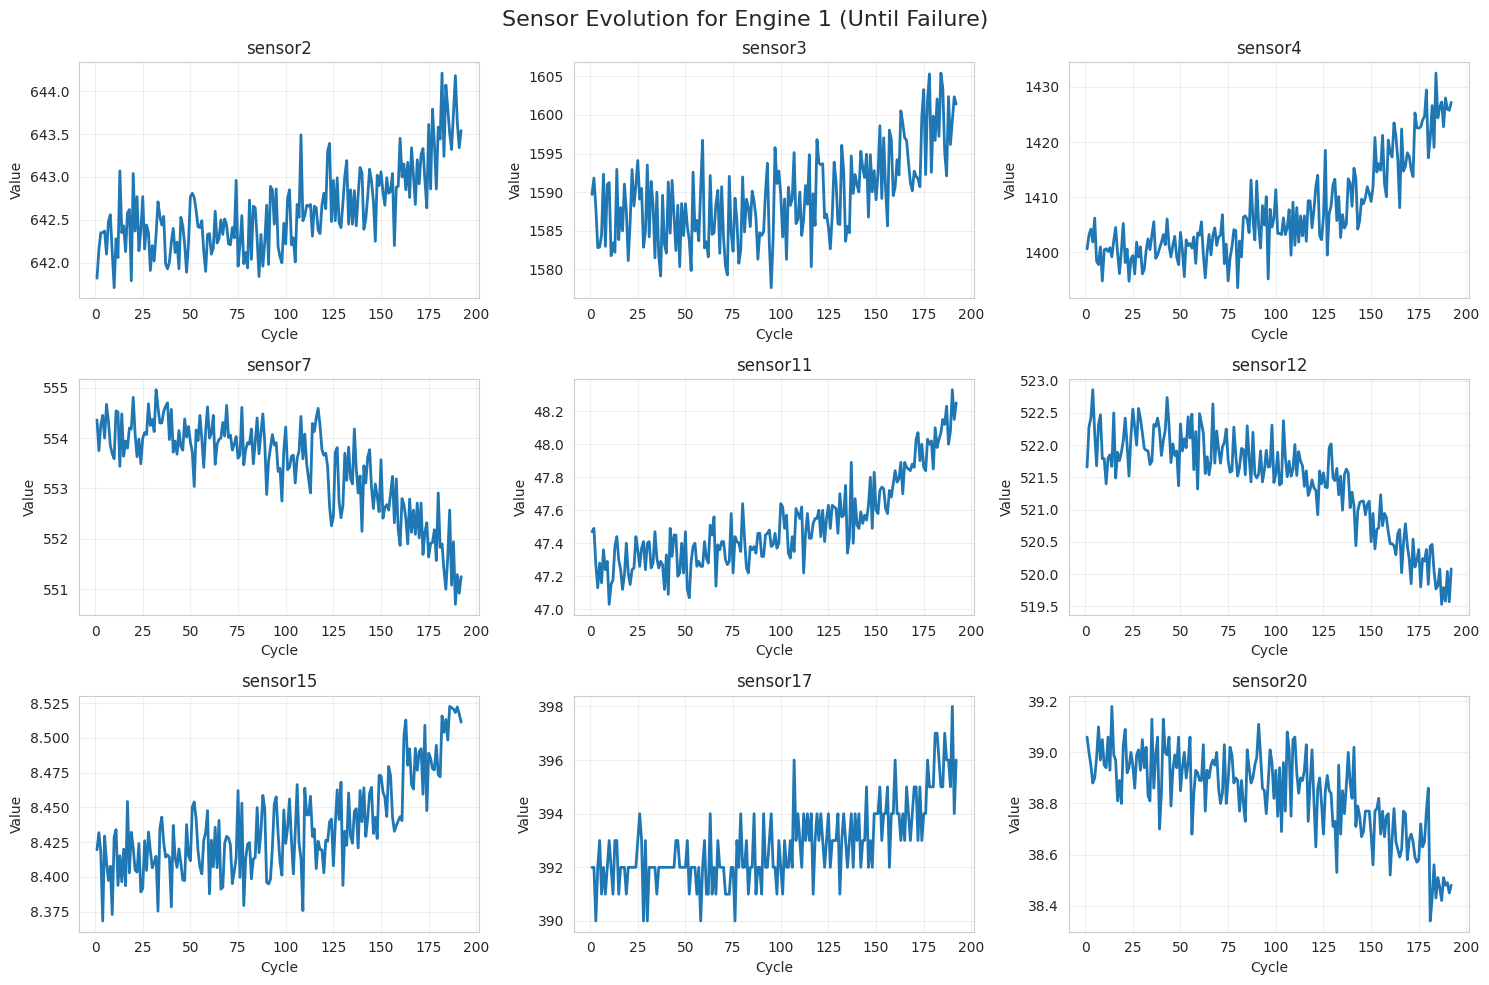

Engine 1 failed after 192 cycles


In [5]:
# Visualiser la dégradation d'un moteur spécifique
engine_id = 1
engine_data = train[train['unit'] == engine_id]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle(f'Sensor Evolution for Engine {engine_id} (Until Failure)', fontsize=16)

sensors_to_plot = ['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor11', 
                   'sensor12', 'sensor15', 'sensor17', 'sensor20']

for idx, sensor in enumerate(sensors_to_plot):
    ax = axes[idx // 3, idx % 3]
    ax.plot(engine_data['cycle'], engine_data[sensor], linewidth=2)
    ax.set_title(sensor)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Engine {engine_id} failed after {engine_data['cycle'].max()} cycles")